# Xử lý ngôn ngữ tự nhiên - CS221.Q21.KHTN

### Thành viên trong nhóm:
- Võ Lê Ngọc Thịnh - 24521710
- Vũ Minh Phương - 24521421
- Nguyễn Hồng Phúc - 24521390
- Nguyễn Duy Khang - 24520755

# Demo Dependency Parsing với spaCy và Stanza

**Chủ đề:** Phân tích cú pháp phụ thuộc (*Dependency Parsing*) trong xử lý ngôn ngữ tự nhiên.

Notebook này được xây dựng nhằm minh họa quy trình phân tích dependency parsing ở cả góc độ sử dụng thư viện và góc độ thuật toán. Nội dung chính bao gồm:

- Thực hiện phân tích cú pháp phụ thuộc bằng hai thư viện NLP phổ biến: **spaCy** và **Stanza**.
- Biểu diễn kết quả dưới dạng quan hệ `head → dependent` và bảng dữ liệu có cấu trúc.
- Trực quan hóa cây phụ thuộc bằng `networkx` và `matplotlib`.
- So sánh kết quả phân tích bằng hai độ đo **UAS** và **LAS** trên một bộ dữ liệu mẫu nhỏ.
- Minh họa trực quan hai hướng tiếp cận thường gặp trong dependency parsing:
  - **Transition-based parsing**: xây dựng cây phụ thuộc thông qua các thao tác trên `stack` và `buffer`.
  - **Graph-based parsing**: lựa chọn cây phụ thuộc tối ưu dựa trên tổng điểm của các cạnh trong đồ thị.

> **Lưu ý khi chạy notebook:** Nên chạy tuần tự các cell từ trên xuống. Ở lần chạy đầu tiên, quá trình cài đặt thư viện và tải mô hình ngôn ngữ có thể mất vài phút.


## 1. Cài đặt thư viện và tải mô hình

Phần này cài đặt các thư viện cần thiết cho toàn bộ notebook, bao gồm:

- `spaCy`: thư viện NLP có hỗ trợ dependency parsing.
- `Stanza`: bộ công cụ NLP của Stanford, hỗ trợ pipeline theo chuẩn Universal Dependencies.
- `networkx` và `matplotlib`: dùng để xây dựng và trực quan hóa cây phụ thuộc.
- `pandas`: dùng để tổ chức và hiển thị kết quả phân tích dưới dạng bảng.

Ngoài ra, notebook tải mô hình tiếng Anh cho spaCy và Stanza để phục vụ các ví dụ minh họa.


In [1]:
!pip install -q spacy stanza networkx matplotlib pandas
!python -m spacy download en_core_web_sm -q

import stanza
stanza.download("en")

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-19 09:42:36 INFO: Downloaded file to /Users/hongphuc/Library/Caches/stanza/1.12.0/resources/resources.json
2026-05-19 09:42:36 INFO: Downloading default packages for language: en (English) ...
2026-05-19 09:42:37 INFO: File exists: /Users/hongphuc/Library/Caches/stanza/1.12.0/resources/en/default.zip
2026-05-19 09:42:40 INFO: Finished downloading models and saved to /Users/hongphuc/Library/Caches/stanza/1.12.0/resources


[['zip', 'default.zip']]

## 2. Khởi tạo các pipeline xử lý ngôn ngữ

Sau khi cài đặt thư viện, ta khởi tạo hai pipeline xử lý ngôn ngữ tự nhiên:

- **spaCy** với mô hình `en_core_web_sm`, hỗ trợ các tác vụ như tokenization, POS tagging và dependency parsing.
- **Stanza** với các processor `tokenize`, `pos`, `lemma` và `depparse`, trong đó `depparse` là thành phần thực hiện phân tích cú pháp phụ thuộc.

Việc sử dụng đồng thời hai thư viện giúp quan sát sự khác biệt trong cách mỗi hệ thống xác định head và nhãn quan hệ phụ thuộc.


In [2]:
import spacy
import stanza
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

nlp_spacy = spacy.load("en_core_web_sm")

nlp_stanza = stanza.Pipeline(
    lang="en",
    processors="tokenize,pos,lemma,depparse",
    use_gpu=False,
    verbose=False
)

## 3. Xây dựng các hàm hỗ trợ

Để tránh lặp lại code và giúp kết quả dễ theo dõi, phần này định nghĩa một số hàm tiện ích:

- Chuyển đầu ra của Stanza và spaCy thành danh sách bản ghi có cấu trúc.
- Chuẩn hóa chỉ số token theo dạng 1-based để thuận tiện khi so sánh với gold standard.
- In các quan hệ phụ thuộc dưới dạng `head → dependent`.
- Vẽ cây dependency từ kết quả parser.
- Tính hai độ đo đánh giá phổ biến là **UAS** và **LAS**.

Các hàm này sẽ được sử dụng xuyên suốt trong những phần tiếp theo của notebook.


In [3]:
def stanza_to_rows(sentence):
    """Parse bằng Stanza và trả về danh sách dòng dạng dict."""
    doc = nlp_stanza(sentence)
    rows = []

    for sent in doc.sentences:
        words = {word.id: word.text for word in sent.words}
        words[0] = "ROOT"
        for word in sent.words:
            rows.append({
                "parser": "Stanza",
                "id": word.id,
                "word": word.text,
                "upos": word.upos,
                "head_id": word.head,
                "head_word": words[word.head],
                "dependency_relation": word.deprel,
            })
    return rows


def spacy_to_rows(sentence):
    """Parse bằng spaCy và trả về danh sách dòng dạng dict, dùng chỉ số 1-based cho dễ so sánh."""
    doc = nlp_spacy(sentence)
    rows = []

    for token in doc:
        token_id = token.i + 1
        head_id = 0 if token.dep_ == "ROOT" else token.head.i + 1
        head_word = "ROOT" if token.dep_ == "ROOT" else token.head.text
        rows.append({
            "parser": "spaCy",
            "id": token_id,
            "word": token.text,
            "upos": token.pos_,
            "head_id": head_id,
            "head_word": head_word,
            "dependency_relation": token.dep_.lower(),
        })
    return rows


def print_head_dependent(rows):
    """In các quan hệ head -> dependent từ bảng parse."""
    for row in rows:
        print(f"{row['head_word']:>12} → {row['word']:<12} {row['dependency_relation']}")


def plot_dependency_tree(rows, title="Dependency Tree"):
    """Vẽ dependency tree từ danh sách rows có id, word, head_id, relation."""
    G = nx.DiGraph()

    labels = {0: "ROOT"}
    for row in rows:
        labels[row["id"]] = row["word"]
        G.add_node(row["id"])
    G.add_node(0)

    for row in rows:
        G.add_edge(row["head_id"], row["id"], label=row["dependency_relation"])

    plt.figure(figsize=(12, 6))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(
        G,
        pos,
        labels=labels,
        with_labels=True,
        node_size=2500,
        font_size=10,
        arrows=True,
        arrowsize=20,
    )
    edge_labels = nx.get_edge_attributes(G, "label")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)
    plt.title(title)
    plt.axis("off")
    plt.show()


def compute_uas_las(gold, system):
    """
    gold/system: dict[token_id] = (head_id, dependency_relation)
    UAS: đúng head
    LAS: đúng cả head và label
    """
    total = 0
    correct_head = 0
    correct_head_and_label = 0

    for token_id, (gold_head, gold_label) in gold.items():
        if token_id not in system:
            continue
        total += 1
        system_head, system_label = system[token_id]

        if gold_head == system_head:
            correct_head += 1
        if gold_head == system_head and gold_label == system_label:
            correct_head_and_label += 1

    return {
        "UAS": correct_head / total if total else 0,
        "LAS": correct_head_and_label / total if total else 0,
        "total_tokens": total,
    }

## 4. Phân tích một câu ví dụ bằng Stanza

Ở bước đầu tiên, ta sử dụng Stanza để phân tích câu:

> **I prefer the morning flight through Denver.**

Mục tiêu của phần này là quan sát đầu ra cơ bản của một dependency parser, bao gồm token, từ loại, head của từng token và nhãn quan hệ phụ thuộc tương ứng.


In [4]:
sentence = "I prefer the morning flight through Denver."

stanza_rows = stanza_to_rows(sentence)
print_head_dependent(stanza_rows)

pd.DataFrame(stanza_rows)

      prefer → I            nsubj
        ROOT → prefer       root
      flight → the          det
      flight → morning      compound
      prefer → flight       obj
      Denver → through      case
      prefer → Denver       obl
      prefer → .            punct


,parser,id,word,upos,head_id,head_word,dependency_relation
0,Stanza,1,I,PRON,2,prefer,nsubj
1,Stanza,2,prefer,VERB,0,ROOT,root
2,Stanza,3,the,DET,5,flight,det
3,Stanza,4,morning,NOUN,5,flight,compound
4,Stanza,5,flight,NOUN,2,prefer,obj
5,Stanza,6,through,ADP,7,Denver,case
6,Stanza,7,Denver,PROPN,2,prefer,obl
7,Stanza,8,.,PUNCT,2,prefer,punct


## 5. Trực quan hóa cây phụ thuộc

Sau khi có kết quả phân tích, ta biểu diễn các quan hệ phụ thuộc dưới dạng một cây có hướng.

Trong cây dependency:

- Mỗi nút tương ứng với một token trong câu hoặc nút `ROOT`.
- Mỗi cạnh có hướng biểu diễn quan hệ từ **head** đến **dependent**.
- Nhãn trên cạnh thể hiện loại quan hệ cú pháp, ví dụ `nsubj`, `obj`, `det`, `obl`.

Việc trực quan hóa giúp dễ nhận biết cấu trúc cú pháp tổng thể của câu.


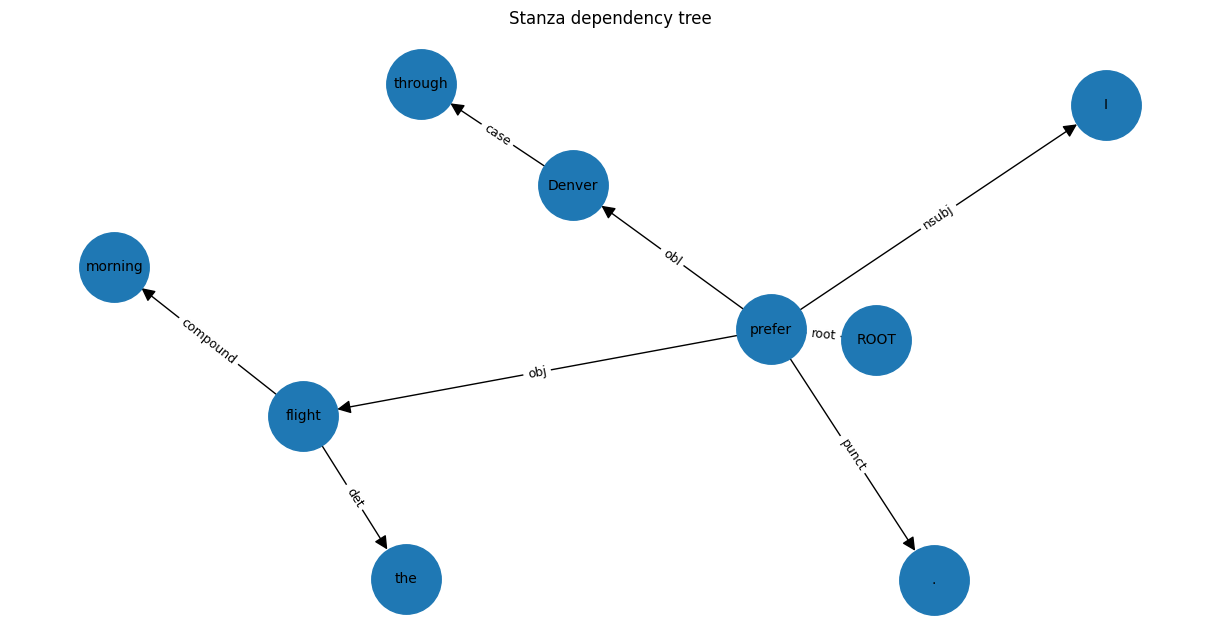

In [5]:
plot_dependency_tree(stanza_rows, title="Stanza dependency tree")

## 6. So sánh kết quả giữa spaCy và Stanza

Phần này phân tích cùng một câu bằng cả spaCy và Stanza, sau đó đặt kết quả vào cùng một bảng để so sánh.

Việc so sánh tập trung vào hai yếu tố:

- **Head**: token nào được chọn làm trung tâm cú pháp của token hiện tại.
- **Dependency relation**: nhãn quan hệ cú pháp giữa token và head của nó.

Trong thực tế, các parser khác nhau có thể đưa ra kết quả không hoàn toàn giống nhau do khác biệt về mô hình, dữ liệu huấn luyện và quy ước gán nhãn.


In [6]:
sentence = "I prefer the morning flight through Denver."

comparison_df = pd.DataFrame(
    spacy_to_rows(sentence) + stanza_to_rows(sentence)
)
comparison_df

,parser,id,word,upos,head_id,head_word,dependency_relation
0,spaCy,1,I,PRON,2,prefer,nsubj
1,spaCy,2,prefer,VERB,0,ROOT,root
2,spaCy,3,the,DET,5,flight,det
3,spaCy,4,morning,NOUN,5,flight,compound
4,spaCy,5,flight,NOUN,2,prefer,dobj
5,spaCy,6,through,ADP,5,flight,prep
6,spaCy,7,Denver,PROPN,6,through,pobj
7,spaCy,8,.,PUNCT,2,prefer,punct
8,Stanza,1,I,PRON,2,prefer,nsubj
9,Stanza,2,prefer,VERB,0,ROOT,root


In [7]:
for parser_name, group in comparison_df.groupby("parser"):
    print("=" * 80)
    print(parser_name)
    print_head_dependent(group.to_dict("records"))

Stanza
      prefer → I            nsubj
        ROOT → prefer       root
      flight → the          det
      flight → morning      compound
      prefer → flight       obj
      Denver → through      case
      prefer → Denver       obl
      prefer → .            punct
spaCy
      prefer → I            nsubj
        ROOT → prefer       root
      flight → the          det
      flight → morning      compound
      prefer → flight       dobj
      flight → through      prep
     through → Denver       pobj
      prefer → .            punct


## 7. Phân tích nhiều câu và thống kê nhãn dependency

Thay vì chỉ xét một câu đơn lẻ, phần này áp dụng Stanza cho một tập câu ví dụ nhỏ. Kết quả phân tích của tất cả các câu được gom lại thành một bảng dữ liệu.

Sau đó, notebook thống kê tần suất xuất hiện của các nhãn dependency. Thống kê này giúp nhận diện những loại quan hệ cú pháp thường gặp trong tập câu đang xét, chẳng hạn như chủ ngữ, tân ngữ, định ngữ hoặc bổ ngữ.


In [8]:
sentences = [
    "United canceled the morning flights to Houston.",
    "Book me the flight through Houston.",
    "We flew to Denver and drove to Steamboat.",
    "The cheapest flight was delayed.",
    "JetBlue canceled our flight this morning which was already late.",
]

all_rows = []
for sent in sentences:
    rows = stanza_to_rows(sent)
    for row in rows:
        row["sentence"] = sent
    all_rows.extend(rows)

all_df = pd.DataFrame(all_rows)
all_df

,parser,id,word,upos,head_id,head_word,dependency_relation,sentence
0,Stanza,1,United,VERB,2,canceled,nsubj,United canceled the morning flights to Houston.
1,Stanza,2,canceled,VERB,0,ROOT,root,United canceled the morning flights to Houston.
2,Stanza,3,the,DET,5,flights,det,United canceled the morning flights to Houston.
3,Stanza,4,morning,NOUN,5,flights,compound,United canceled the morning flights to Houston.
4,Stanza,5,flights,NOUN,2,canceled,obj,United canceled the morning flights to Houston.
5,Stanza,6,to,ADP,7,Houston,case,United canceled the morning flights to Houston.
6,Stanza,7,Houston,PROPN,5,flights,nmod,United canceled the morning flights to Houston.
7,Stanza,8,.,PUNCT,2,canceled,punct,United canceled the morning flights to Houston.
8,Stanza,1,Book,VERB,0,ROOT,root,Book me the flight through Houston.
9,Stanza,2,me,PRON,1,Book,iobj,Book me the flight through Houston.


In [9]:
relation_counts = (
    all_df["dependency_relation"]
    .value_counts()
    .reset_index()
)
relation_counts.columns = ["dependency_relation", "count"]
relation_counts

,dependency_relation,count
0,punct,5
1,root,5
2,nsubj,4
3,det,4
4,case,4
5,obj,3
6,nmod,2
7,obl,2
8,aux:pass,1
9,advmod,1


## 8. Đánh giá parser bằng UAS và LAS

Để đánh giá chất lượng dependency parser, ta so sánh kết quả dự đoán của parser với một **gold standard** được gán nhãn thủ công. Trong notebook này, gold standard được xây dựng trên một số câu ngắn nhằm phục vụ mục đích minh họa.

Hai độ đo được sử dụng là:

- **UAS (*Unlabeled Attachment Score*)**: tỷ lệ token được gán đúng head, không xét nhãn quan hệ.
- **LAS (*Labeled Attachment Score*)**: tỷ lệ token được gán đúng cả head và nhãn dependency.

Nói cách khác, LAS nghiêm ngặt hơn UAS vì yêu cầu parser dự đoán đúng cả cấu trúc liên kết lẫn loại quan hệ cú pháp.

> **Lưu ý:** Bộ gold standard trong notebook có kích thước nhỏ, chỉ dùng để minh họa cách tính điểm. Kết quả này không nên được xem là benchmark chính thức cho spaCy hoặc Stanza.


In [10]:
gold_data = {
    "She bought a book": {
        "words": ["She", "bought", "a", "book"],
        "heads": [2, 0, 4, 2],
        "deprels": ["nsubj", "root", "det", "obj"],
    },
    "The cat sat on the mat": {
        "words": ["The", "cat", "sat", "on", "the", "mat"],
        "heads": [2, 3, 0, 6, 6, 3],
        "deprels": ["det", "nsubj", "root", "case", "det", "obl"],
    },
    "They will arrive tomorrow": {
        "words": ["They", "will", "arrive", "tomorrow"],
        "heads": [3, 3, 0, 3],
        "deprels": ["nsubj", "aux", "root", "obl"],
    },
}


def rows_to_system(rows):
    return {
        row["id"]: (row["head_id"], row["dependency_relation"].lower())
        for row in rows
    }

scores = []
for sentence, gold_info in gold_data.items():
    gold = {
        idx + 1: (head, deprel)
        for idx, (head, deprel) in enumerate(zip(gold_info["heads"], gold_info["deprels"]))
    }

    systems = {
        "spaCy": rows_to_system(spacy_to_rows(sentence)),
        "Stanza": rows_to_system(stanza_to_rows(sentence)),
    }

    for parser_name, system in systems.items():
        result = compute_uas_las(gold, system)
        scores.append({
            "sentence": sentence,
            "parser": parser_name,
            "UAS": round(result["UAS"], 3),
            "LAS": round(result["LAS"], 3),
            "total_tokens": result["total_tokens"],
        })

score_df = pd.DataFrame(scores)
score_df

,sentence,parser,UAS,LAS,total_tokens
0,She bought a book,spaCy,1.000,0.750,4
1,She bought a book,Stanza,1.000,1.000,4
2,The cat sat on the mat,spaCy,0.667,0.667,6
3,The cat sat on the mat,Stanza,1.000,1.000,6
4,They will arrive tomorrow,spaCy,1.000,0.750,4
5,They will arrive tomorrow,Stanza,1.000,0.750,4


## 9. Phân tích chi tiết các token đúng và sai

Sau khi tính điểm tổng quát bằng UAS và LAS, ta tiếp tục kiểm tra chi tiết ở cấp độ từng token. Ví dụ được sử dụng là câu:

> **Book me the flight through Houston.**

Ở phần này, mỗi token được so sánh giữa gold standard và kết quả parser theo các tiêu chí:

- Head trong gold standard và head do hệ thống dự đoán.
- Nhãn dependency trong gold standard và nhãn do hệ thống dự đoán.
- Token có đúng head hay không.
- Token có đúng cả head và nhãn hay không.

Cách phân tích này giúp xác định cụ thể parser sai ở đâu, thay vì chỉ nhìn vào điểm số tổng quát.


In [11]:
sentence = "Book me the flight through Houston."

# Gold parse 1-based; head = 0 nghĩa là ROOT.
gold = {
    1: (0, "root"),
    2: (1, "iobj"),
    3: (4, "det"),
    4: (1, "obj"),
    5: (6, "case"),
    6: (4, "nmod"),
    7: (1, "punct"),
}

rows = stanza_to_rows(sentence)
system = rows_to_system(rows)

word_lookup = {row["id"]: row["word"] for row in rows}
word_lookup[0] = "ROOT"

detail_rows = []
for row in rows:
    token_id = row["id"]
    gold_head, gold_label = gold[token_id]
    system_head, system_label = system[token_id]

    detail_rows.append({
        "word": row["word"],
        "gold_head": word_lookup.get(gold_head, "ROOT"),
        "system_head": word_lookup.get(system_head, "ROOT"),
        "gold_label": gold_label,
        "system_label": system_label,
        "head_correct": gold_head == system_head,
        "label_correct": gold_label == system_label,
        "las_correct": gold_head == system_head and gold_label == system_label,
    })

pd.DataFrame(detail_rows)

,word,gold_head,system_head,gold_label,system_label,head_correct,label_correct,las_correct
0,Book,ROOT,ROOT,root,root,True,True,True
1,me,Book,Book,iobj,iobj,True,True,True
2,the,flight,flight,det,det,True,True,True
3,flight,Book,Book,obj,obj,True,True,True
4,through,Houston,Houston,case,case,True,True,True
5,Houston,flight,flight,nmod,nmod,True,True,True
6,.,Book,Book,punct,punct,True,True,True


## 10. Minh họa transition-based parsing

Transition-based parsing là một hướng tiếp cận xây dựng cây phụ thuộc thông qua chuỗi thao tác tuần tự. Parser duy trì hai cấu trúc chính:

- **Stack**: lưu các token đang được xử lý.
- **Buffer**: chứa các token chưa được đưa vào stack.

Trong ví dụ minh họa, ta sử dụng ba thao tác cơ bản:

- `SHIFT`: chuyển token đầu tiên từ buffer lên stack.
- `LEFTARC`: tạo quan hệ phụ thuộc theo hướng head → dependent và loại dependent khỏi stack.
- `RIGHTARC`: tạo quan hệ phụ thuộc theo hướng head → dependent và loại dependent khỏi stack.

Mục tiêu của phần này là minh họa trực quan cách một parser có thể từng bước xây dựng cây dependency. Đây là mô phỏng đơn giản, không phải là một dependency parser hoàn chỉnh.


In [12]:
words = ["Book", "me", "the", "morning", "flight"]

stack = ["ROOT"]
buffer = words.copy()
relations = []

actions = [
    ("SHIFT", None),
    ("SHIFT", None),
    ("RIGHTARC", ("Book", "me", "iobj")),
    ("SHIFT", None),
    ("SHIFT", None),
    ("SHIFT", None),
    ("LEFTARC", ("flight", "morning", "compound")),
    ("LEFTARC", ("flight", "the", "det")),
    ("RIGHTARC", ("Book", "flight", "obj")),
    ("RIGHTARC", ("ROOT", "Book", "root")),
]

snapshots = []

for step, (action, relation) in enumerate(actions, start=1):
    before_stack = stack.copy()
    before_buffer = buffer.copy()

    if action == "SHIFT":
        if buffer:
            stack.append(buffer.pop(0))
    elif action in {"LEFTARC", "RIGHTARC"}:
        head, dependent, label = relation
        relations.append((head, dependent, label))
        if dependent in stack:
            stack.remove(dependent)

    snapshots.append({
        "step": step,
        "action": action,
        "relation": relation,
        "stack_before": before_stack,
        "buffer_before": before_buffer,
        "stack_after": stack.copy(),
        "buffer_after": buffer.copy(),
    })

pd.DataFrame(snapshots)

,step,action,relation,stack_before,buffer_before,stack_after,buffer_after
0,1,SHIFT,None,[ROOT],"[Book, me, the, morning, flight]","[ROOT, Book]","[me, the, morning, flight]"
1,2,SHIFT,None,"[ROOT, Book]","[me, the, morning, flight]","[ROOT, Book, me]","[the, morning, flight]"
2,3,RIGHTARC,"(Book, me, iobj)","[ROOT, Book, me]","[the, morning, flight]","[ROOT, Book]","[the, morning, flight]"
3,4,SHIFT,None,"[ROOT, Book]","[the, morning, flight]","[ROOT, Book, the]","[morning, flight]"
4,5,SHIFT,None,"[ROOT, Book, the]","[morning, flight]","[ROOT, Book, the, morning]",[flight]
5,6,SHIFT,None,"[ROOT, Book, the, morning]",[flight],"[ROOT, Book, the, morning, flight]",[]
6,7,LEFTARC,"(flight, morning, compound)","[ROOT, Book, the, morning, flight]",[],"[ROOT, Book, the, flight]",[]
7,8,LEFTARC,"(flight, the, det)","[ROOT, Book, the, flight]",[],"[ROOT, Book, flight]",[]
8,9,RIGHTARC,"(Book, flight, obj)","[ROOT, Book, flight]",[],"[ROOT, Book]",[]
9,10,RIGHTARC,"(ROOT, Book, root)","[ROOT, Book]",[],[ROOT],[]


In [13]:
print("Dependency relations created by transition demo:")
for head, dep, label in relations:
    print(f"{head} → {dep}    {label}")

Dependency relations created by transition demo:
Book → me    iobj
flight → morning    compound
flight → the    det
Book → flight    obj
ROOT → Book    root


## 11. Minh họa graph-based parsing bằng maximum spanning arborescence

Graph-based parsing xem bài toán dependency parsing như một bài toán lựa chọn cây tối ưu trên đồ thị có hướng.

Trong cách tiếp cận này:

- Mỗi token được xem là một nút trong đồ thị.
- Mỗi cạnh có hướng `head → dependent` được gán một điểm số thể hiện mức độ phù hợp.
- Parser cần chọn tập cạnh tạo thành một cây phụ thuộc hợp lệ có tổng điểm cao nhất.

Ở ví dụ dưới đây, ta sử dụng hàm `maximum_spanning_arborescence` của `networkx` để chọn cây phụ thuộc có tổng trọng số lớn nhất từ một đồ thị các cạnh ứng viên.


In [14]:
nodes = ["ROOT", "Book", "that", "flight"]

edges = [
    ("ROOT", "Book", 12),
    ("ROOT", "that", 4),
    ("ROOT", "flight", 4),
    ("Book", "that", 5),
    ("Book", "flight", 8),
    ("that", "Book", 6),
    ("that", "flight", 7),
    ("flight", "Book", 5),
    ("flight", "that", 7),
]

G = nx.DiGraph()
G.add_nodes_from(nodes)
for head, dep, score in edges:
    G.add_edge(head, dep, weight=score)

mst = nx.maximum_spanning_arborescence(G)

print("Selected dependency edges:")
for head, dep, data in mst.edges(data=True):
    print(f"{head} → {dep}    score={data['weight']}")

Selected dependency edges:
ROOT → Book    score=12
Book → flight    score=8
flight → that    score=7


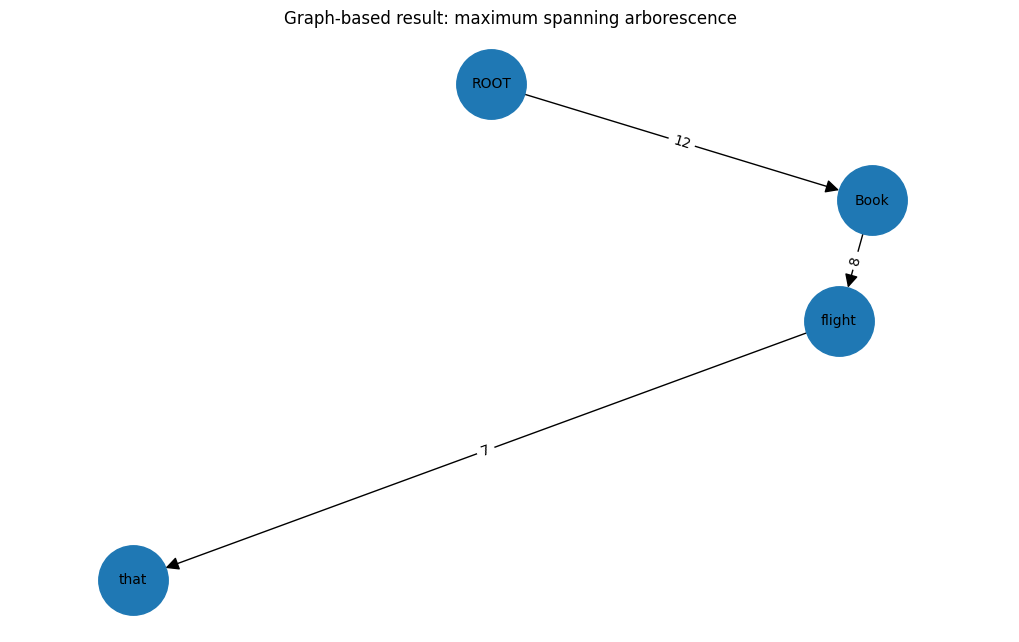

In [15]:
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(mst, seed=42)
nx.draw(mst, pos, with_labels=True, node_size=2500, font_size=10, arrows=True, arrowsize=20)
edge_labels = nx.get_edge_attributes(mst, "weight")
nx.draw_networkx_edge_labels(mst, pos, edge_labels=edge_labels)
plt.title("Graph-based result: maximum spanning arborescence")
plt.axis("off")
plt.show()

## 12. Phân tích câu có cấu trúc phức tạp hơn

Phần cuối của demo sử dụng một câu có cấu trúc cú pháp phức tạp hơn:

> **JetBlue canceled our flight this morning which was already late.**

Câu này có thêm các thành phần như cụm danh từ, trạng ngữ thời gian và mệnh đề quan hệ. Vì vậy, đây là ví dụ phù hợp để quan sát cách dependency parser xử lý các thành phần bổ nghĩa và quan hệ phụ thuộc trong một câu dài hơn.


In [16]:
complex_sentence = "JetBlue canceled our flight this morning which was already late."

rows = stanza_to_rows(complex_sentence)
print_head_dependent(rows)
pd.DataFrame(rows)

    canceled → JetBlue      nsubj
        ROOT → canceled     root
      flight → our          nmod:poss
    canceled → flight       obj
     morning → this         det
    canceled → morning      obl:tmod
        late → which        nsubj
        late → was          cop
        late → already      advmod
      flight → late         acl:relcl
    canceled → .            punct


,parser,id,word,upos,head_id,head_word,dependency_relation
0,Stanza,1,JetBlue,PROPN,2,canceled,nsubj
1,Stanza,2,canceled,VERB,0,ROOT,root
2,Stanza,3,our,PRON,4,flight,nmod:poss
3,Stanza,4,flight,NOUN,2,canceled,obj
4,Stanza,5,this,DET,6,morning,det
5,Stanza,6,morning,NOUN,2,canceled,obl:tmod
6,Stanza,7,which,PRON,10,late,nsubj
7,Stanza,8,was,AUX,10,late,cop
8,Stanza,9,already,ADV,10,late,advmod
9,Stanza,10,late,ADJ,4,flight,acl:relcl


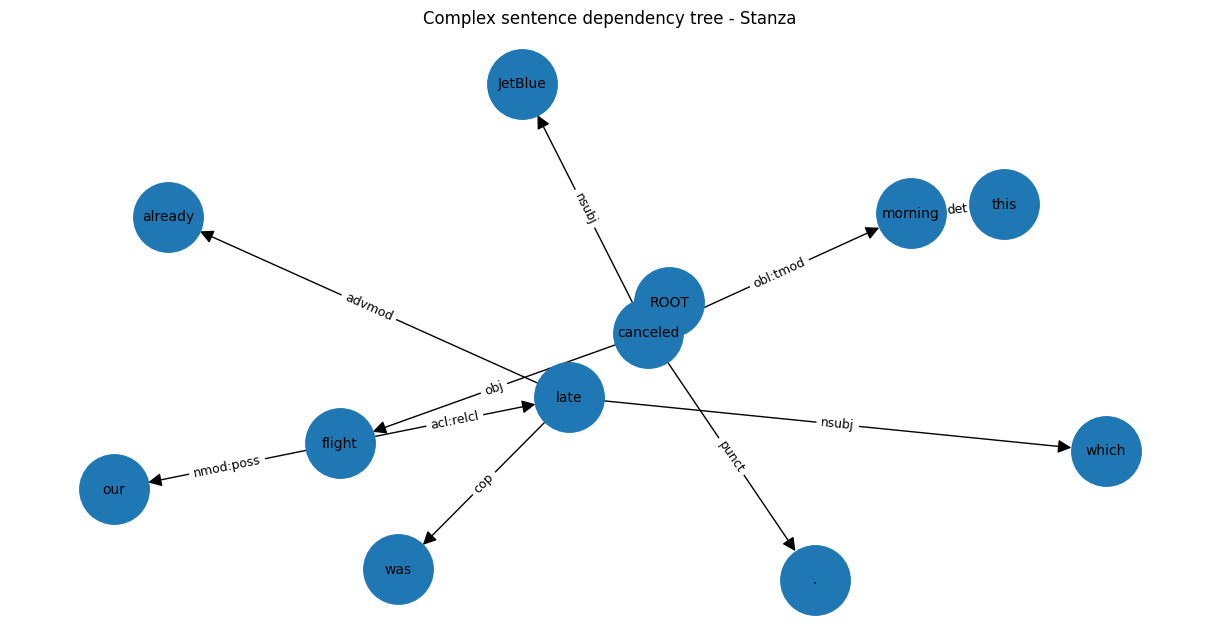

In [17]:
plot_dependency_tree(rows, title="Complex sentence dependency tree - Stanza")

## 13. Kết luận

Notebook đã trình bày một quy trình minh họa dependency parsing từ mức sử dụng công cụ đến mức giải thích ý tưởng thuật toán. Các nội dung chính bao gồm:

1. **Sử dụng thư viện NLP:** spaCy và Stanza được dùng để phân tích câu, xác định head và nhãn quan hệ dependency cho từng token.
2. **Biểu diễn và trực quan hóa kết quả:** kết quả parser được chuyển thành bảng dữ liệu, in dưới dạng quan hệ `head → dependent` và trực quan hóa thành cây phụ thuộc.
3. **Đánh giá parser:** hai độ đo UAS và LAS được sử dụng để so sánh kết quả parser với gold standard thủ công.
4. **Minh họa thuật toán:** notebook mô phỏng hai hướng tiếp cận tiêu biểu là transition-based parsing và graph-based parsing.

Thông qua các ví dụ này, có thể thấy dependency parsing không chỉ giúp xác định cấu trúc cú pháp của câu, mà còn là nền tảng quan trọng cho nhiều bài toán xử lý ngôn ngữ tự nhiên như trích xuất thông tin, phân tích ngữ nghĩa, hỏi đáp và xây dựng hệ thống hiểu văn bản.
